<h1>Redukcija dimenzionalnosti</h1>

<p>rateći notebook uz seminarski rad, u kome će biti primeri korišćenja nekih od tehnika za redukciju dimenzionalnosti o kojima je bilo priče u seminarskom.
Koristiće se dva modela (k-NN i Logitstic Regression) koji će biti držani fiksno, a menjaće se sama reprezentacija podataka. </p>
<ul>
<li>k-NN - model zasnovan na rastojanju, koji najjače pati od *prokletstva dimenzionalnosti.</li>
<li>Logistička regresija = linearni model, otporniji na veliki broj atributa.</li>
</ul>

<h1>1 Podešavanje i biblioteke </h1>

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
RS = 42
np.random.seed(RS)
plt.rcParams["figure.figsize"] = (10, 6)

<h1>2 Modeli i pomoćne funkcije </h1>

In [3]:
def make_models():
    return {
        "k-NN":   KNeighborsClassifier(n_neighbors=5),
        "LogReg": LogisticRegression(max_iter=5000),
    }

In [4]:
def acc_for(Xtr, Xte, ytr, yte):
    out = {}
    for name, m in make_models().items():
        m.fit(Xtr, ytr)
        out[name] = accuracy_score(yte, m.predict(Xte))
    return out

In [5]:
results = []

def evaluate(dataset, technique, Xtr, Xte, ytr, yte):
    for name, model in make_models().items():
        t0 = time.perf_counter(); model.fit(Xtr, ytr);        fit_t  = time.perf_counter() - t0
        t0 = time.perf_counter(); pred = model.predict(Xte);  pred_t = time.perf_counter() - t0
        results.append({
            "dataset": dataset, "technique": technique, "model": name,
            "n_dims": Xtr.shape[1],
            "accuracy": round(accuracy_score(yte, pred), 4),
            "macro_f1": round(f1_score(yte, pred, average="macro"), 4),
            "fit_s":     round(fit_t, 4),
            "predict_s": round(pred_t, 4),
        })

In [6]:
def prepare(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RS)
    scaler = StandardScaler().fit(Xtr)
    return {
        "Xtr_raw": Xtr,                 "Xte_raw": Xte,
        "Xtr": scaler.transform(Xtr),   "Xte": scaler.transform(Xte),
        "ytr": ytr,                     "yte": yte,
    }

<h1>3 Datasetovi</h1>

<ul>
<li>synthetic - veštački skup sa mnogo beskorisnih atributa (kontrolisani primer).</li>
<li>breast_cancer - realan skup sa 30 interpretabilnih atributa.</li>
<li>digits - slike cifara 8×8 (64 atributa), pogodne za vizualizaciju.</li>
</ul>

In [7]:
from sklearn.datasets import make_classification
X_syn, y_syn = make_classification(
    n_samples=2000, n_features=500,
    n_informative=15, n_redundant=35, n_repeated=0,
    n_classes=2, shuffle=False, random_state=RS)
print("oblik:", X_syn.shape)
print("klase:", np.unique(y_syn, return_counts=True))

oblik: (2000, 500)
klase: (array([0, 1]), array([1003,  997]))


In [8]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
df_bc = pd.DataFrame(X_bc, columns=bc.feature_names)
print("oblik:", X_bc.shape)
print("klase:", np.unique(y_bc, return_counts=True))

oblik: (569, 30)
klase: (array([0, 1]), array([212, 357]))


In [9]:
from sklearn.datasets import load_digits
dg = load_digits()
X_dig, y_dig = dg.data, dg.target
print("oblik:", X_dig.shape, "| klasa:", len(np.unique(y_dig)))
print("opseg piksela:", X_dig.min(), "-", X_dig.max())

oblik: (1797, 64) | klasa: 10
opseg piksela: 0.0 - 16.0


In [10]:
d_syn = prepare(X_syn, y_syn)
d_bc  = prepare(X_bc,  y_bc)
d_dig = prepare(X_dig, y_dig)

<h1>4 EDA</h1>

<h2>2.1 Synthetic</h2>
<p>Veštački skup sa 500 atributa, od kojih je samo ~50 nosi informaciju (15 informativnih + 35
redundantnih), a ostalih ~450 je čist šum. Pošto koristimo

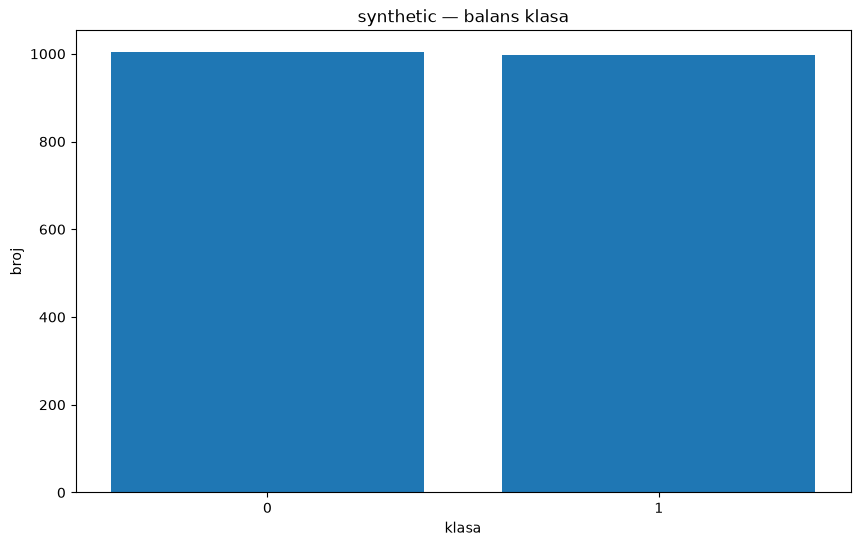

In [11]:
vals, counts = np.unique(y_syn, return_counts=True)
plt.bar(vals.astype(str), counts)
plt.title("synthetic — balans klasa"); plt.xlabel("klasa"); plt.ylabel("broj"); plt.show()

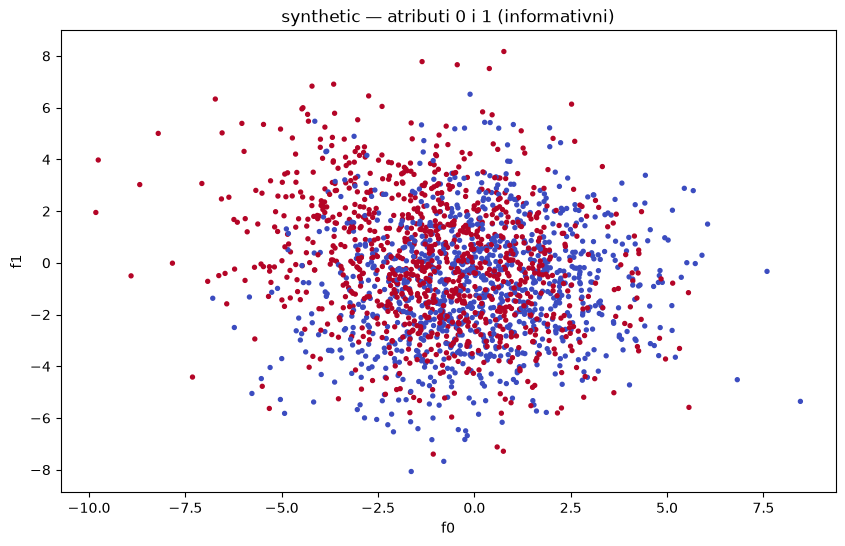

In [12]:
plt.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap="coolwarm", s=8)
plt.title("synthetic — atributi 0 i 1 (informativni)"); plt.xlabel("f0"); plt.ylabel("f1"); plt.show()

<h2>2.2 Breast Cancer</h2>
<p>Realan skup sa 569 uzoraka i 30 interpretabilnih atributa (mere ćelijskih jedara). Klase su
maligna (0) i benigna (1)</p1>

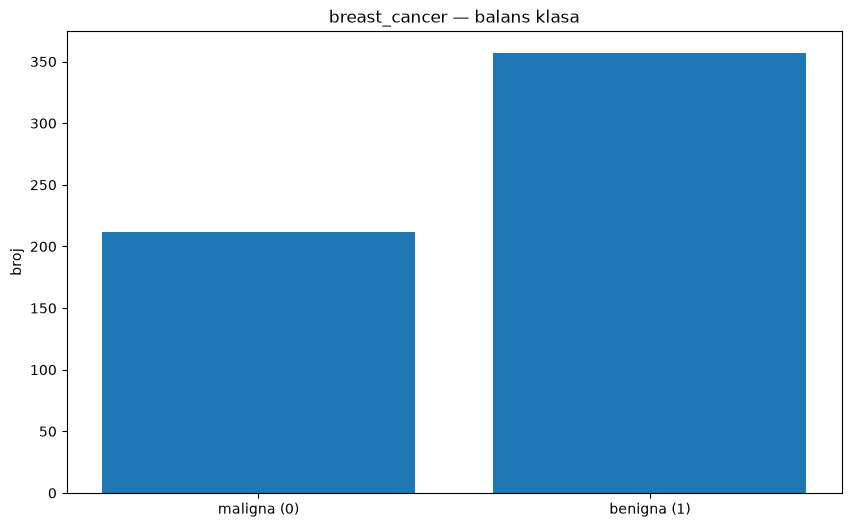

In [13]:
vals, counts = np.unique(y_bc, return_counts=True)
plt.bar(["maligna (0)", "benigna (1)"], counts)
plt.title("breast_cancer — balans klasa"); plt.ylabel("broj"); plt.show()

In [14]:
df_bc.iloc[:, :6].describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10
std,3.52,4.30,24.30,351.91,0.01,0.05
min,6.98,9.71,43.79,143.50,0.05,0.02
25%,11.70,16.17,75.17,420.30,0.09,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09
75%,15.78,21.80,104.10,782.70,0.11,0.13
max,28.11,39.28,188.50,2501.00,0.16,0.35


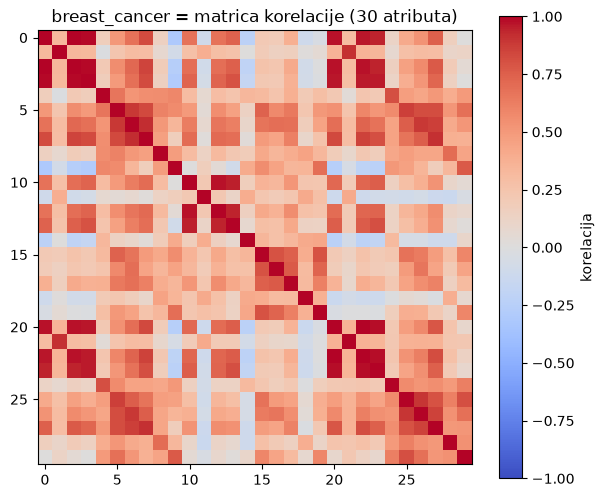

In [15]:
corr = df_bc.corr().values
plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="korelacija")
plt.title("breast_cancer = matrica korelacije (30 atributa)"); plt.show()

<h2>2.3 Digits</h2>
<p>Slike rukom pisanih cifara 8×8 (64 piksela kao atributi), 10 klasa. Pošto su atributi pikseli,
skup je idealan za vizualizaciju ekstrakcije. Vrednosti piksela su u opsegu 0–16.</p>

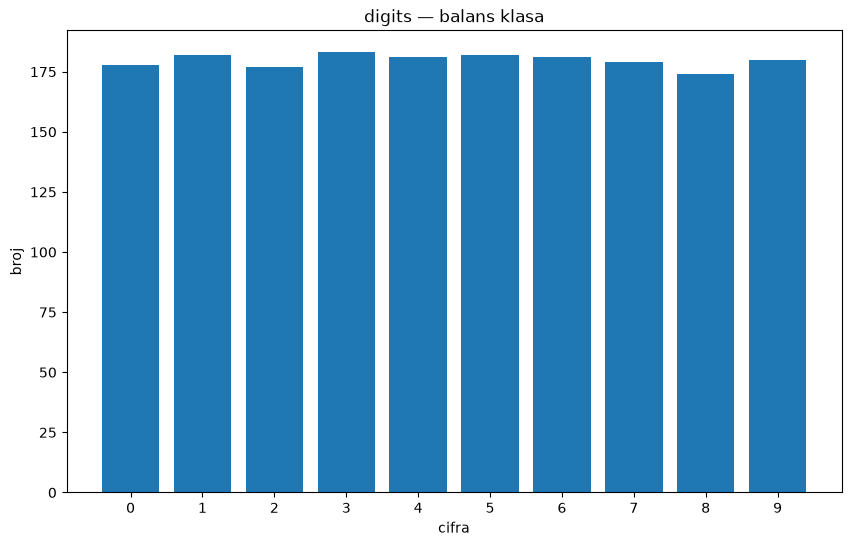

In [16]:
vals, counts = np.unique(y_dig, return_counts=True)
plt.bar(vals.astype(str), counts)
plt.title("digits — balans klasa"); plt.xlabel("cifra"); plt.ylabel("broj"); plt.show()

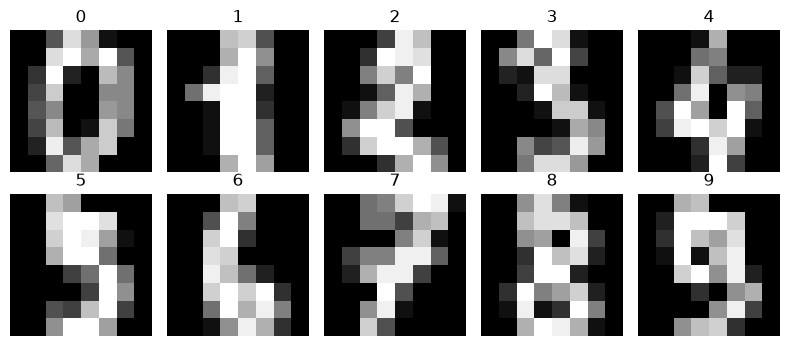

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(dg.images[i], cmap="gray")
    ax.set_title(str(dg.target[i]))
    ax.axis("off")
plt.tight_layout(); plt.show()

<h1>5 Baseline (svi atributi)</h1>

In [18]:
evaluate("synthetic",     "baseline", d_syn["Xtr"], d_syn["Xte"], d_syn["ytr"], d_syn["yte"])
evaluate("breast_cancer", "baseline", d_bc["Xtr"],  d_bc["Xte"],  d_bc["ytr"],  d_bc["yte"])
evaluate("digits",        "baseline", d_dig["Xtr"], d_dig["Xte"], d_dig["ytr"], d_dig["yte"])
pd.DataFrame(results)

,dataset,technique,model,n_dims,accuracy,macro_f1,fit_s,predict_s
0,synthetic,baseline,k-NN,500,0.7140,0.7121,0.0018,1.6803
1,synthetic,baseline,LogReg,500,0.7400,0.7400,0.0137,0.0005
2,breast_cancer,baseline,k-NN,30,0.9790,0.9772,0.0005,0.0023
3,breast_cancer,baseline,LogReg,30,0.9860,0.9850,0.0034,0.0001
4,digits,baseline,k-NN,64,0.9644,0.9642,0.0004,0.0022
5,digits,baseline,LogReg,64,0.9778,0.9776,0.0116,0.0002


<h1>6 Feature selection</h1>

In [19]:
def summary(dataset):
    s = pd.DataFrame(results)
    s = s[s.dataset == dataset]
    acc = s.pivot(index="technique", columns="model", values="accuracy")
    dims = s.drop_duplicates("technique").set_index("technique")["n_dims"]
    out = acc.copy()
    out["dims"] = dims
    out["k-NN Δ"]   = (acc["k-NN"]   - acc.loc["baseline", "k-NN"]).round(3)
    out["LogReg Δ"] = (acc["LogReg"] - acc.loc["baseline", "LogReg"]).round(3)
    return out.sort_values("dims")

In [20]:
def select_and_eval(dataset, technique, selector, d):
    selector.fit(d["Xtr"], d["ytr"])
    Xtr_s, Xte_s = selector.transform(d["Xtr"]), selector.transform(d["Xte"])
    evaluate(dataset, technique, Xtr_s, Xte_s, d["ytr"], d["yte"])
    print(f"{technique:22s} {d['Xtr'].shape[1]:>3} -> {Xtr_s.shape[1]} atributa")
    return selector

<h2>3.1 Synthetic</h2>

<h3>Mutual Information <i>(filter)</i></h3><p>Bira k atributa sa najvećom uzajamnom informacijom u odnosu na klasu (hvata i nelinearne veze)</p>

In [21]:
from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif
mi = partial(mutual_info_classif, random_state=RS)
mi_sel = select_and_eval("synthetic", "mutual info (k=20)", SelectKBest(mi, k=20), d_syn)

mutual info (k=20)     500 -> 20 atributa


<h3>RFE = Recursive Feature Elimination <i>(wrapper)</i></h3><p>Iterativno uklanja najslabije atribute; selekciju vodi LogReg, a ocenjuju je k-NN i LogReg.</p>

In [22]:
from sklearn.feature_selection import RFE
rfe_sel = select_and_eval("synthetic", "RFE (20)",
                RFE(LogisticRegression(max_iter=5000), n_features_to_select=20, step=0.1), d_syn)

RFE (20)               500 -> 20 atributa


<h3>Random Forest importance <i>(embedded, tree-based)</i></h3><p>Zadržava 20 atributa sa najvećom važnošću po Random Forest modelu.</p>

In [23]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
rf_syn = RandomForestClassifier(n_estimators=200, random_state=RS)
rf_sel = select_and_eval("synthetic", "RF importance",
                         SelectFromModel(rf_syn, threshold=-np.inf, max_features=20), d_syn)

RF importance          500 -> 20 atributa


<h3>XGBoost importance <i>(embedded, tree-based)</i></h3><p>Gradient boost često daje preciznije važnosti od običnog Random Forest-a; zadržava 20 najvažnijih atributa.</p>

In [24]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                    eval_metric="logloss", random_state=RS, verbosity=0)
xgb_sel = select_and_eval("synthetic", "XGBoost importance",
                          SelectFromModel(xgb, threshold=-np.inf, max_features=20), d_syn)

XGBoost importance     500 -> 20 atributa


<h1>EDA posle feature enineering-a</h1>

<p>Atributi su neimenovani, pa su prikazani po indeksu. Indeksi &lt; 50 su korisni
(informativni/redundantni), a &ge; 50 su šum. Zanimljivo je videti i oko kojih se atributa
sve tri tehnike slažu.</p>

In [25]:
def kept_idx(sel):
    return np.where(sel.get_support())[0]

for name, sel in [("mutual info", mi_sel), ("RFE", rfe_sel), ("RF importance", rf_sel), ("XGBoost", xgb_sel)]:
    idx = kept_idx(sel)
    print(f"{name:14s} signal(<50)={int((idx<50).sum()):2d}  šum={int((idx>=50).sum()):2d}  ->", [int(i) for i in idx])

common = set(kept_idx(mi_sel)) & set(kept_idx(rfe_sel)) & set(kept_idx(rf_sel)) & set(kept_idx(xgb_sel))
print("\nsve četiri tehnike biraju istih", len(common), "atributa:", sorted(int(i) for i in common))

mutual info    signal(<50)=15  šum= 5  -> [4, 6, 8, 12, 20, 23, 26, 29, 33, 34, 38, 39, 40, 43, 49, 193, 300, 364, 430, 465]
RFE            signal(<50)=19  šum= 1  -> [3, 5, 6, 8, 10, 12, 13, 14, 16, 22, 26, 29, 32, 34, 39, 43, 44, 48, 49, 470]
RF importance  signal(<50)=20  šum= 0  -> [0, 2, 4, 6, 8, 13, 15, 17, 18, 20, 26, 29, 33, 34, 36, 39, 40, 42, 43, 49]
XGBoost        signal(<50)=18  šum= 2  -> [0, 2, 6, 7, 8, 13, 24, 27, 28, 29, 33, 35, 39, 40, 42, 43, 46, 47, 388, 433]

sve četiri tehnike biraju istih 5 atributa: [6, 8, 29, 39, 43]


<p><b>Poređenje sa baseline-om</b>:</p>

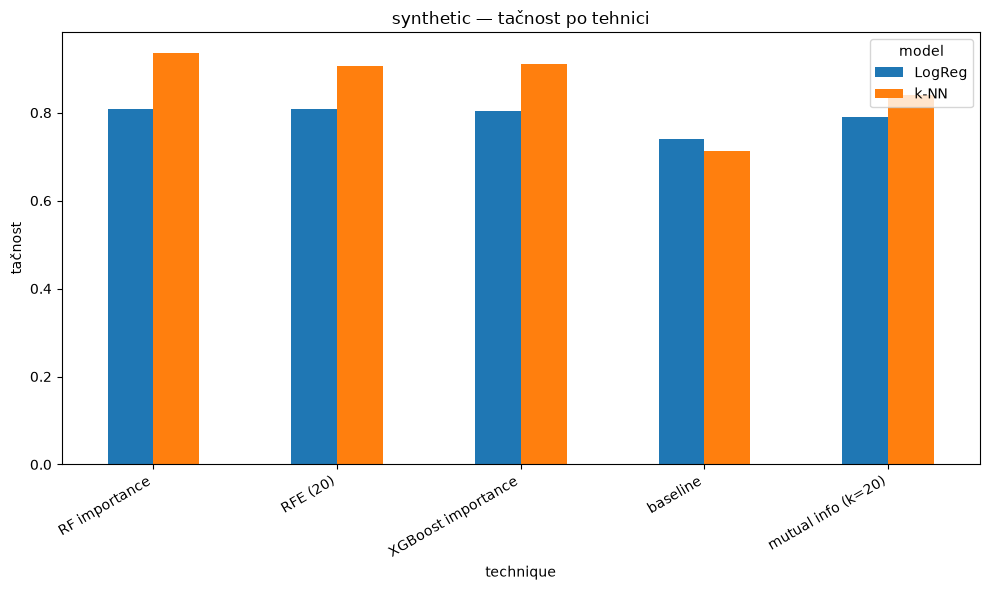

In [26]:
sub = pd.DataFrame(results)
sub = sub[sub.dataset == "synthetic"]
sub.pivot(index="technique", columns="model", values="accuracy").plot(kind="bar")
plt.title("synthetic — tačnost po tehnici"); plt.ylabel("tačnost")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [27]:
summary("synthetic")

model,LogReg,k-NN,dims,k-NN Δ,LogReg Δ
technique,,,,,
RF importance,0.808,0.936,20,0.222,0.068
RFE (20),0.808,0.906,20,0.192,0.068
XGBoost importance,0.804,0.910,20,0.196,0.064
mutual info (k=20),0.790,0.840,20,0.126,0.050
baseline,0.740,0.714,500,0.000,0.000


<h3>Analiza - synthetic</h3>
<p>Ovaj skup je namerno napravljen tako da redukcija mora da pomogne: od 500 atributa samo ~50
nosi signal, a ostalo je šum. Tabela iznad pokazuje koliko je svaka tehnika promenila tačnost u
odnosu na baseline.</p>
<ul>
<li><b>Baseline (500 atributa).</b> k-NN je ovde najslabiji (~0.71) jer u 500-dimenzionom prostoru
~450 šumnih osa - sve tačke postaju približno podjednako udaljene, pa
glasanje suseda gubi smisao. LogReg je nešto bolji (~0.74) jer regularizacija male koeficijente
šumnih atributa gura ka nuli, pa ih praktično ignoriše.</li>
<li><b>Mutual Information <i>(+0.13 za k-NN)</i>.</b> Spuštanje na 20 atributa diže k-NN na ~0.84.
MI gleda svaki atribut posebno i hvata (i nelinearnu) vezu sa klasom, ali ne uzima u obzir
interakcije ni redundansu, pa ume da izabere više međusobno sličnih atributa — dobitak je realan,
ali manji nego kod ostalih.</li>
<li><b>RFE <i>(+0.19 za k-NN)</i>.</b> k-NN skače na ~0.91. RFE iterativno izbacuje najslabije
atribute koristeći ceo model (LogReg), pa vrednuje atribute u kombinaciji, a ne pojedinačno —
otud bolji izbor od MI. Cena je sporije računanje, jer se model trenira mnogo puta.</li>
<li><b>Random Forest importance <i>(+0.22 za k-NN)</i>.</b> Najbolji rezultat, ~0.94. Šumski model
meri važnost kroz stvarne podele i hvata nelinearne efekte; EDA iznad potvrđuje da je svih 20
izabranih atributa iz korisnog opsega (&lt;50), bez ijednog šumnog — selekcija je praktično
rekonstruisala „pravu” strukturu skupa.</li>
</ul>
<p>Zs k-NN je redukcija ovde presudna (do +22 procentna poena), dok je za LogReg efekat
mnogo manji (+5 do +7) jer je već bio otporan na šum. Bonus: sa 500 na 20 dimenzija vreme
predikcije k-NN-a padne otprilike 10× — manje dimenzija znači i bržu inferenciju.</p>

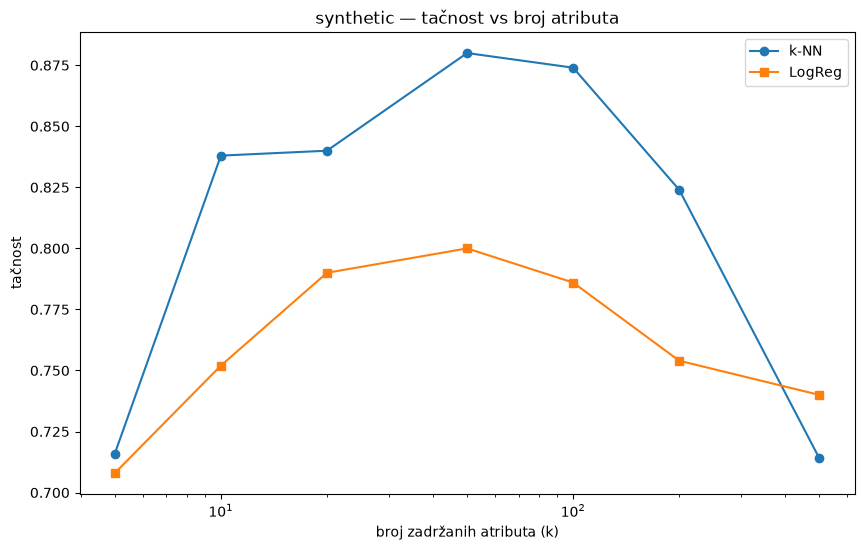

In [28]:
ks = [5, 10, 20, 50, 100, 200, 500]
knn_acc, log_acc = [], []
for k in ks:
    sel = SelectKBest(mi, k=k).fit(d_syn["Xtr"], d_syn["ytr"])
    a = acc_for(sel.transform(d_syn["Xtr"]), sel.transform(d_syn["Xte"]), d_syn["ytr"], d_syn["yte"])
    knn_acc.append(a["k-NN"]); log_acc.append(a["LogReg"])
plt.plot(ks, knn_acc, "o-", label="k-NN")
plt.plot(ks, log_acc, "s-", label="LogReg")
plt.xscale("log")
plt.xlabel("broj zadržanih atributa (k)"); plt.ylabel("tačnost")
plt.title("synthetic — tačnost vs broj atributa"); plt.legend(); plt.show()

<h2>3.2 Breast Cancer</h2>
<p>Drugačiji set tehnika: <b>Variance Threshold</b> (filter), <b>ANOVA F-test</b> (filter) i
<b>L1 / LASSO</b> (embedded)</p>

<h3>Variance Threshold <i>(filter)</i></h3>
<p>Uklanja atribute sa malom varijansom. Primenjuje se na sirovim podacima (pre skaliranja), pa
preživele atribute se tek onda vrši skaliranje.</p>

In [29]:
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=0.01).fit(d_bc["Xtr_raw"])
Xtr_v, Xte_v = vt.transform(d_bc["Xtr_raw"]), vt.transform(d_bc["Xte_raw"])
sc = StandardScaler().fit(Xtr_v)
evaluate("breast_cancer", "variance threshold", sc.transform(Xtr_v), sc.transform(Xte_v), d_bc["ytr"], d_bc["yte"])
print("variance threshold", X_bc.shape[1], "->", Xtr_v.shape[1], "atributa")

variance threshold 30 -> 14 atributa


<h3>ANOVA F-test <i>(filter)</i></h3><p>Rangira atribute po ANOVA F-vrednosti (jačina linearne veze sa klasom) i zadržava najboljih k.</p>

In [30]:
from sklearn.feature_selection import f_classif
anova_sel = select_and_eval("breast_cancer", "ANOVA F-test (k=15)", SelectKBest(f_classif, k=15), d_bc)

ANOVA F-test (k=15)     30 -> 15 atributa


<h3>L1 / LASSO <i>(embedded, regularization)</i></h3><p>L1 kazna gura deo koeficijenata na nulu; zadržavaju se atribute sa koeficijentom različitim od nule.</p>

In [31]:
l1_bc = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000, random_state=RS)
l1_sel = select_and_eval("breast_cancer", "L1 / LASSO", SelectFromModel(l1_bc), d_bc)

L1 / LASSO              30 -> 7 atributa


c:\Users\Wibes\anaconda3\envs\dimensionality-reduction-py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Wibes\anaconda3\envs\dimensionality-reduction-py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


<h3>Ridge (L2) <i>(embedded, regularization)</i></h3><p>L2 kazna smanjuje koeficijente, ali ih ne anulira, pa L2 sam po sebi ne vrši selekciju. Da bi se uporedili, ručno se zadržavaju 10 atributa sa najvećim apsolutnim koeficijentom.</p>

In [32]:
ridge_bc = LogisticRegression(penalty="l2", C=0.1, max_iter=5000, random_state=RS)
ridge_sel = select_and_eval("breast_cancer", "Ridge (top 10)",
                            SelectFromModel(ridge_bc, threshold=-np.inf, max_features=10), d_bc)

Ridge (top 10)          30 -> 10 atributa


c:\Users\Wibes\anaconda3\envs\dimensionality-reduction-py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


<p><b>EDA posle inženjeringa atributa:</b>

<h3>Elastic Net <i>(embedded, regularization)</i></h3><p>Kombinuje L1 i L2 (ovde l1_ratio=0.5): zadržava sparsity L1-a uz stabilnost L2-a kod korelisanih atributa, pa prirodno bira podskup.</p>

In [33]:
en_bc = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                           C=0.1, max_iter=5000, random_state=RS)
en_sel = select_and_eval("breast_cancer", "Elastic Net", SelectFromModel(en_bc), d_bc)

Elastic Net             30 -> 14 atributa


c:\Users\Wibes\anaconda3\envs\dimensionality-reduction-py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


<h4>Koji su atributi zadržani?</h4>
<p>Kod realnog skupa selekcija je interpretabilna, vidi se tačno koje je atribute svaka tehnika zadržala i koje sve tri smatraju važnim.</p>

In [34]:
names = np.array(bc.feature_names)
for tech, sel in [("Variance Threshold", vt), ("ANOVA F-test", anova_sel), ("L1 / LASSO", l1_sel),
                  ("Ridge (top 10)", ridge_sel), ("Elastic Net", en_sel)]:
    kept = list(names[sel.get_support()])
    print(f"{tech} ({len(kept)} atributa):")
    for k in kept:
        print("   -", k)
    print()

common = (set(names[anova_sel.get_support()]) & set(names[l1_sel.get_support()])
          & set(names[ridge_sel.get_support()]) & set(names[en_sel.get_support()]))
print("zajedničke za ANOVA/L1/Ridge/ElasticNet:", sorted(str(x) for x in common))

Variance Threshold (14 atributa):
   - mean radius
   - mean texture
   - mean perimeter
   - mean area
   - radius error
   - texture error
   - perimeter error
   - area error
   - worst radius
   - worst texture
   - worst perimeter
   - worst area
   - worst compactness
   - worst concavity

ANOVA F-test (15 atributa):
   - mean radius
   - mean perimeter
   - mean area
   - mean compactness
   - mean concavity
   - mean concave points
   - radius error
   - perimeter error
   - area error
   - worst radius
   - worst perimeter
   - worst area
   - worst compactness
   - worst concavity
   - worst concave points

L1 / LASSO (7 atributa):
   - mean concave points
   - radius error
   - worst radius
   - worst texture
   - worst smoothness
   - worst concave points
   - worst symmetry

Ridge (top 10) (10 atributa):
   - mean radius
   - mean texture
   - mean concave points
   - radius error
   - worst radius
   - worst texture
   - worst perimeter
   - worst area
   - worst concave 

<p><b>Poređenje sa baseline</b></p>

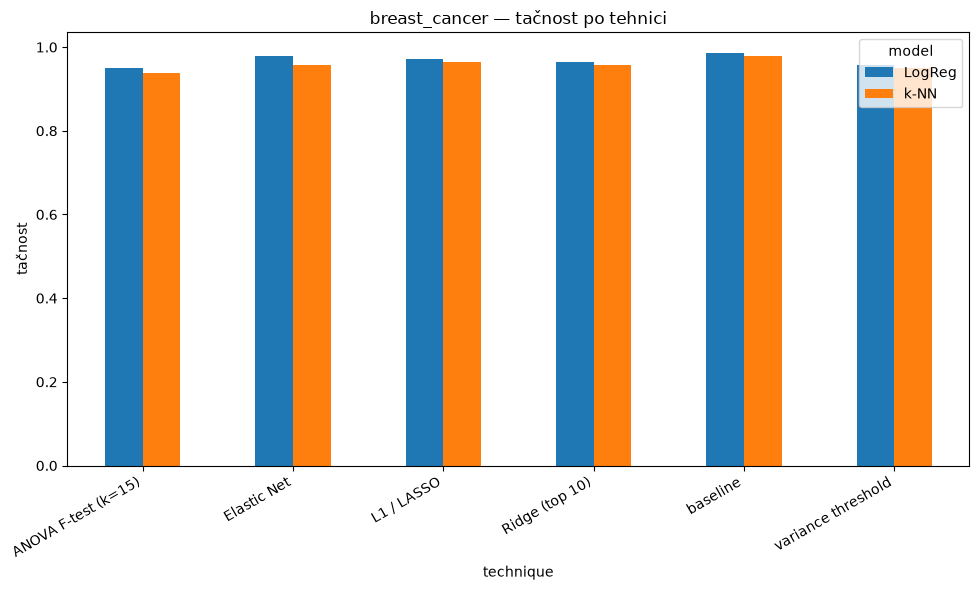

In [35]:
sub = pd.DataFrame(results)
sub = sub[sub.dataset == "breast_cancer"]
sub.pivot(index="technique", columns="model", values="accuracy").plot(kind="bar")
plt.title("breast_cancer — tačnost po tehnici"); plt.ylabel("tačnost")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [36]:
summary("breast_cancer")

model,LogReg,k-NN,dims,k-NN Δ,LogReg Δ
technique,,,,,
L1 / LASSO,0.972,0.9650,7,-0.014,-0.014
Ridge (top 10),0.965,0.9580,10,-0.021,-0.021
Elastic Net,0.979,0.9580,14,-0.021,-0.007
variance threshold,0.958,0.9510,14,-0.028,-0.028
ANOVA F-test (k=15),0.951,0.9371,15,-0.042,-0.035
baseline,0.986,0.9790,30,0.000,0.000


<h3>Analiza</h3>
<p>Za razliku od synthetic skupa, ovde je svih 30 atributa relativno informativno i međusobno
korelisano (videti matricu korelacije u EDA). Skup je već niskodimenzionalan i čist, pa od
redukcije nema mnogo da se dobije, sve tri tehnike blago smanjuju tačnost, ali u zamenu za
jednostavniji i interpretabilniji model.</p>
<ul>
<li><b>Baseline (30 atributa).</b> Oba modela su već vrlo jaka (k-NN ~0.98, LogReg ~0.99). Nema
šuma koji bi redukcija uklonila, pa je baseline teško nadmašiti.</li>
<li><b>Variance Threshold <i>(−0.028)</i>.</b> Uklonio je 16 atributa (30→14). Problem je što prag
varijanse gleda samo razmeru atributa, a ne njihovu vezu sa klasom, neki izbačeni atributi imali
su malu varijansu, ali korisnu informaciju. Najslabija strategija ovde.</li>
<li><b>ANOVA F-test <i>(−0.035 do −0.042)</i>.</b> 15 atributa. ANOVA meri samo linearnu razliku
srednjih vrednosti po klasama i posmatra atribute izolovano, pa zanemaruje njihovu međusobnu
korelaciju; izabere deo redundantnih i ispusti neke komplementarne, otud najveći pad.</li>
<li><b>L1 / LASSO <i>(−0.014, samo 7 atributa)</i>.</b> Najbolji kompromis. L1 bira atribute
zajednički unutar jednog modela i prirodno izbacuje redundantne, pa od 30 zadrži samo 7 koji
pokrivaju gotovo sav signal. Izlistani nazivi („worst radius”, „worst concave points”…) klinički
su smisleni, to je velika prednost selekcije: rezultat ostaje interpretabilan.</li>
<li><b>Ridge (L2).</b> Zadržava sve atribute sa malim koeficijentima i sam po sebi ne vrši
selekciju; kada ručno uzmemo 10 najjačih, rezultat je sličan ostalima. Ridge je prirodno metoda
za <i>regularizaciju</i>, a ne za izbor atributa, to je ključna razlika u odnosu na L1.</li>
<li><b>Elastic Net.</b> Mešavina L1 i L2; daje sparsity sličan L1-u, ali stabilnije bira među
međusobno korelisanim atributima (kojih ovde ima dosta), pa je dobar kompromis kada atributi
nisu nezavisni.</li>
</ul>
<p>PKada je skup već mali i kvalitetan, redukcija ne služi da podigne tačnost nego da
uprosti model uz minimalan gubitak. L1 to radi najbolje,  4× manje atributa uz pad od svega ~1.4%.</p>

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
logreg = LogisticRegression(max_iter=5000).fit(d_bc["Xtr"], d_bc["ytr"])
pred = logreg.predict(d_bc["Xte"])
print(confusion_matrix(d_bc["yte"], pred))
print(classification_report(d_bc["yte"], pred, target_names=["maligna", "benigna"]))

[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

     maligna       0.98      0.98      0.98        53
     benigna       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



<h1>7 Feature extraction</h1>
<p>Umesto biranja postojećih, kreiraju se novi atributi kao transformacija starih. Radi se na skupu <b>digits</b>, koji je pogodan za vizualizaciju.</p>

<h2>7.1 Digits</h2>
<p>Tehnike: <b>PCA</b>, <b>LDA</b>, <b>t-SNE</b> (samo vizualizacija) i <b>Autoencoder</b>.</p>

<h3>PCA</h3><p>Nenadzirana linearna ekstrakcija; najpre se gleda koliko komponenti treba za 95% varijanse.</p>

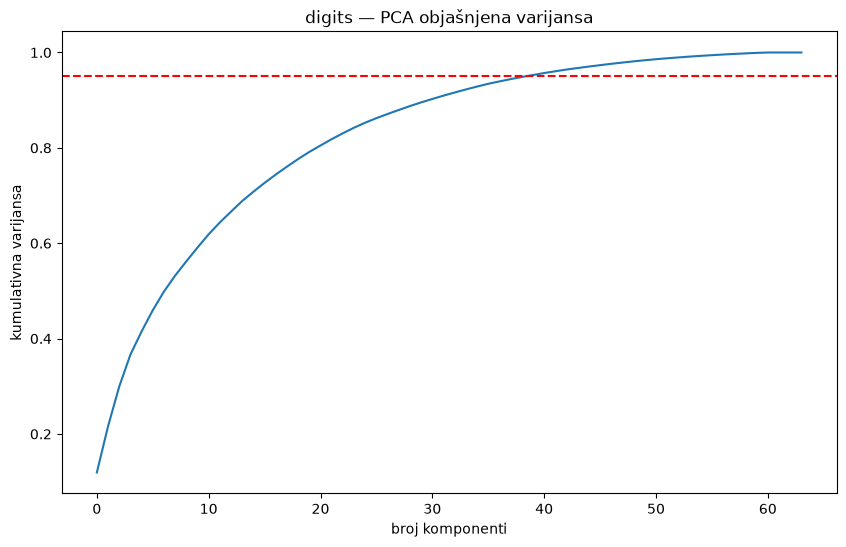

In [38]:
from sklearn.decomposition import PCA
pca_full = PCA().fit(d_dig["Xtr"])
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.axhline(0.95, color="red", ls="--")
plt.xlabel("broj komponenti"); plt.ylabel("kumulativna varijansa")
plt.title("digits — PCA objašnjena varijansa"); plt.show()

In [39]:
pca = PCA(n_components=0.95, random_state=RS).fit(d_dig["Xtr"])
Xtr_p, Xte_p = pca.transform(d_dig["Xtr"]), pca.transform(d_dig["Xte"])
print("komponenti za 95% varijanse:", Xtr_p.shape[1])
evaluate("digits", "PCA (95% var)", Xtr_p, Xte_p, d_dig["ytr"], d_dig["yte"])

komponenti za 95% varijanse: 40


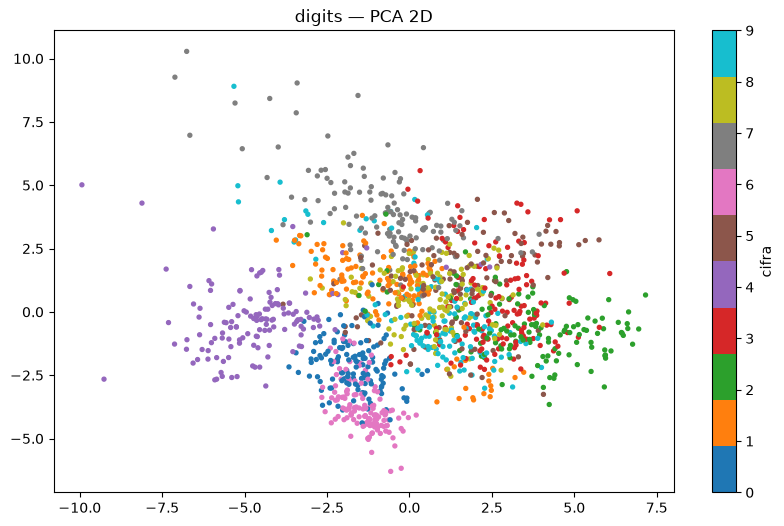

In [40]:
p2 = PCA(n_components=2, random_state=RS).fit_transform(d_dig["Xtr"])
plt.scatter(p2[:, 0], p2[:, 1], c=d_dig["ytr"], cmap="tab10", s=8)
plt.title("digits — PCA 2D"); plt.colorbar(label="cifra"); plt.show()

<h3>LDA</h3>
<p>Nadzirana ekstrakcija; broj komponenti je ograničen na broj_klasa − 1 (9).</p>

In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis().fit(d_dig["Xtr"], d_dig["ytr"])
Xtr_l, Xte_l = lda.transform(d_dig["Xtr"]), lda.transform(d_dig["Xte"])
print("LDA komponenti:", Xtr_l.shape[1])
evaluate("digits", "LDA", Xtr_l, Xte_l, d_dig["ytr"], d_dig["yte"])

LDA komponenti: 9


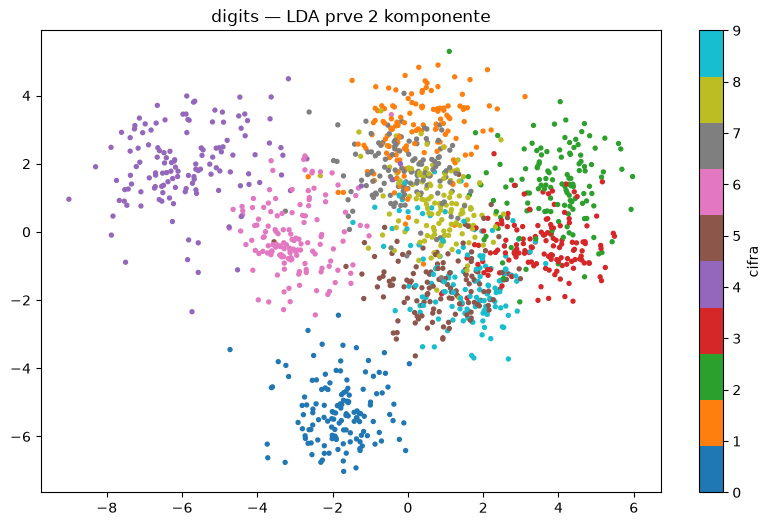

In [42]:
plt.scatter(Xtr_l[:, 0], Xtr_l[:, 1], c=d_dig["ytr"], cmap="tab10", s=8)
plt.title("digits — LDA prve 2 komponente"); plt.colorbar(label="cifra"); plt.show()

<h3>t-SNE <i>(samo vizualizacija)</i></h3>
<p>t-SNE nema projekciju za nove tačke, pa se korsiti samo za vizualizaciju strukture, ne u klasifikacionom pipeline-u.</p>

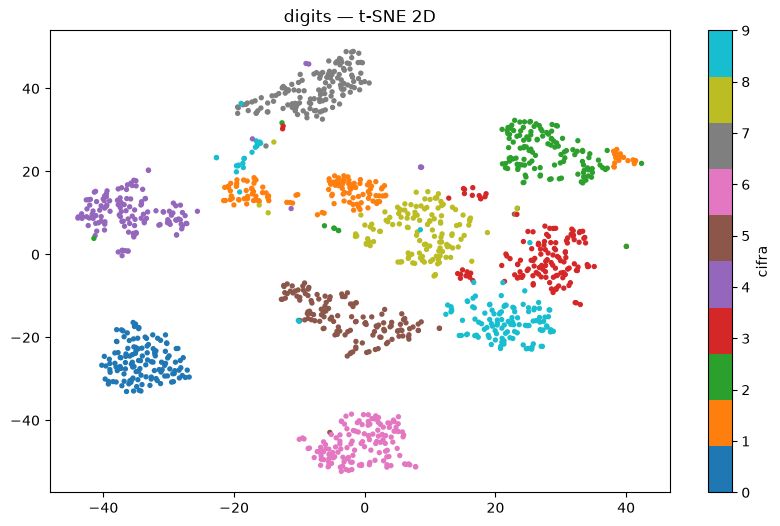

In [43]:
from sklearn.manifold import TSNE
emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=RS).fit_transform(d_dig["Xtr"])
plt.scatter(emb[:, 0], emb[:, 1], c=d_dig["ytr"], cmap="tab10", s=8)
plt.title("digits — t-SNE 2D"); plt.colorbar(label="cifra"); plt.show()

<h3>Autoencoder <i>(nelinearna ekstrakcija)</i></h3>
<p>Neuronska mreža sažima sliku u 10D latentni prostor; koristimo enkoder da dobijemo nove atribute..</p>

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, Model
tf.random.set_seed(RS)

X_ae_tr = d_dig["Xtr_raw"] / 16.0
X_ae_te = d_dig["Xte_raw"] / 16.0

inp = layers.Input(shape=(64,))
x   = layers.Dense(32, activation="relu")(inp)
lat = layers.Dense(10, activation="relu", name="latent")(x)
x   = layers.Dense(32, activation="relu")(lat)
out = layers.Dense(64, activation="sigmoid")(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(X_ae_tr, X_ae_tr, epochs=50, batch_size=32, verbose=0)
print("trening autoenkodera zavrsen")

trening autoenkodera zavrsen


In [45]:
encoder = Model(autoencoder.input, autoencoder.get_layer("latent").output)
Xtr_ae = encoder.predict(X_ae_tr, verbose=0)
Xte_ae = encoder.predict(X_ae_te, verbose=0)
sc_ae = StandardScaler().fit(Xtr_ae)
print("latentne dimenzije:", Xtr_ae.shape[1])
evaluate("digits", "Autoencoder (10D)", sc_ae.transform(Xtr_ae), sc_ae.transform(Xte_ae), d_dig["ytr"], d_dig["yte"])

latentne dimenzije: 10


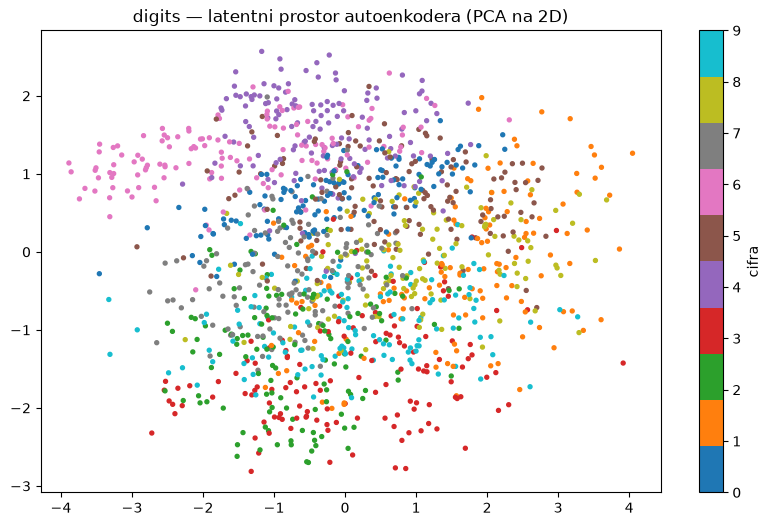

In [46]:
ae2 = PCA(n_components=2, random_state=RS).fit_transform(sc_ae.transform(Xtr_ae))
plt.scatter(ae2[:, 0], ae2[:, 1], c=d_dig["ytr"], cmap="tab10", s=8)
plt.title("digits — latentni prostor autoenkodera (PCA na 2D)"); plt.colorbar(label="cifra"); plt.show()

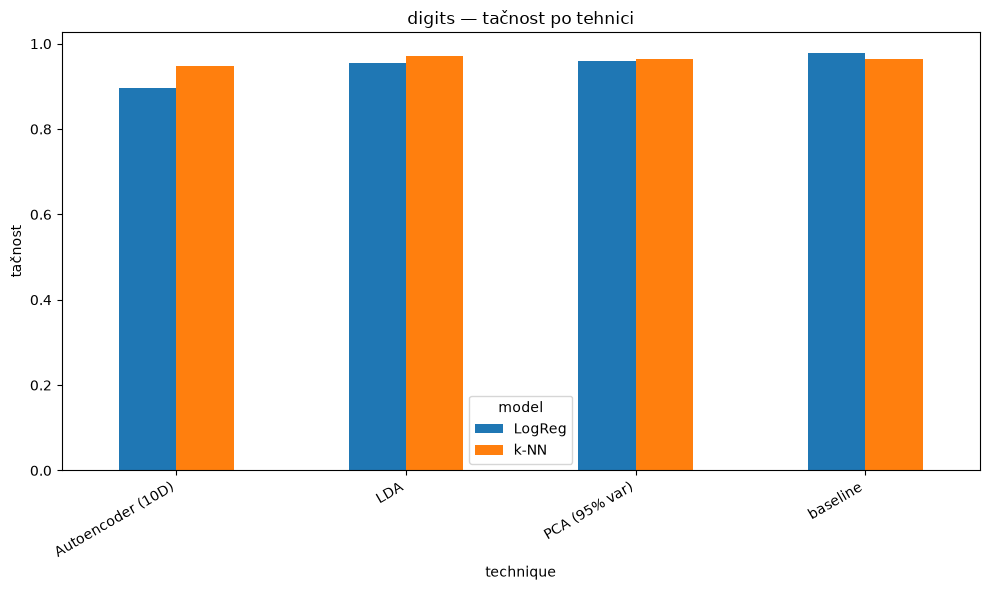

In [47]:
sub = pd.DataFrame(results)
sub = sub[sub.dataset == "digits"]
sub.pivot(index="technique", columns="model", values="accuracy").plot(kind="bar")
plt.title("digits — tačnost po tehnici"); plt.ylabel("tačnost")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [48]:
summary("digits")

model,LogReg,k-NN,dims,k-NN Δ,LogReg Δ
technique,,,,,
LDA,0.9556,0.9711,9,0.007,-0.022
Autoencoder (10D),0.8956,0.9467,10,-0.018,-0.082
PCA (95% var),0.9600,0.9644,40,0.000,-0.018
baseline,0.9778,0.9644,64,0.000,0.000


<h3>Analiza</h3>
<p>Ovde se poredi ekstrakcija (pravljenje novih atributa) na 64 piksela. Cilj nije toliko podizanje
tačnosti (baseline je već visok) koliko jaka kompresija uz očuvanje tačnosti.</p>
<ul>
<li><b>Baseline (64 piksela).</b> k-NN ~0.96, LogReg ~0.98.</li>
<li><b>PCA (40 komponenti, 95% varijanse).</b> k-NN ostaje isti (~0.96) uz 64→40 dimenzija, dok
LogReg blago padne (~−0.02). PCA bira pravce najveće varijanse bez obzira na klase, pa zadrži
skoro svu korisnu informaciju; poslednjih nekoliko procenata varijanse koje odbaci sadrži fine
detalje korisne linearnom modelu.</li>
<li><b>LDA (9 komponenti, +0.007 za k-NN).</b> Najjača kompresija, 64→9m, a k-NN čak blago
poraste (~0.97). Pošto LDA koristi oznake klasa i traži pravce koji maksimalno razdvajaju klase,
9 komponenti (broj_klasa−1) dovoljno je da se 10 cifara lepo razdvoji; to se vidi i na 2D
projekciji. LogReg malo padne jer mu 9 osa oduzme deo slobode.</li>
<li><b>Autoencoder (10D, −0.031 za k-NN).</b> Najslabiji u ovom poređenju. Razlozi: mreža je mala
i kratko trenirana, a uči da rekonstruiše piksele (MSE gubitak), ne da razdvaja klasem, latentni
prostor je optimizovan za vernu rekonstrukciju, a ne za klasifikaciju. Uz dublju mrežu, više epoha
ili nadgledani gubitak rezultat bi bio bolji; ovako lepo pokazuje da nelinearna ekstrakcija nije
„besplatan ručak”.</li>
<li><b>t-SNE.</b> Nije u tabeli jer služi samo za vizualizaciju (nema projekciju za nove tačke). Na
2D prikazu se cifre grupišu u jasne klastere, što potvrđuje da podaci imaju nisko-dimenzionu
strukturu koju ekstrakcija može da iskoristi.</li>
</ul>
<p>Pouka: nadzirana ekstrakcija (LDA) ovde pobeđuje, najveća kompresija (9 dimenzija) uz najbolju
k-NN tačnost, jer koristi informaciju o klasama. Nenadzirane metode (PCA, AE) čuvaju strukturu
podataka, ali ne nužno onu koja je najbolja baš za klasifikaciju.</p>

<h3>Koliko komponenti je dovoljno?</h3><p>Tačnost u zavisnosti od broja PCA komponenti, pokazuje koliko malo komponenti je dovoljno za skoro punu tačnost.</p>

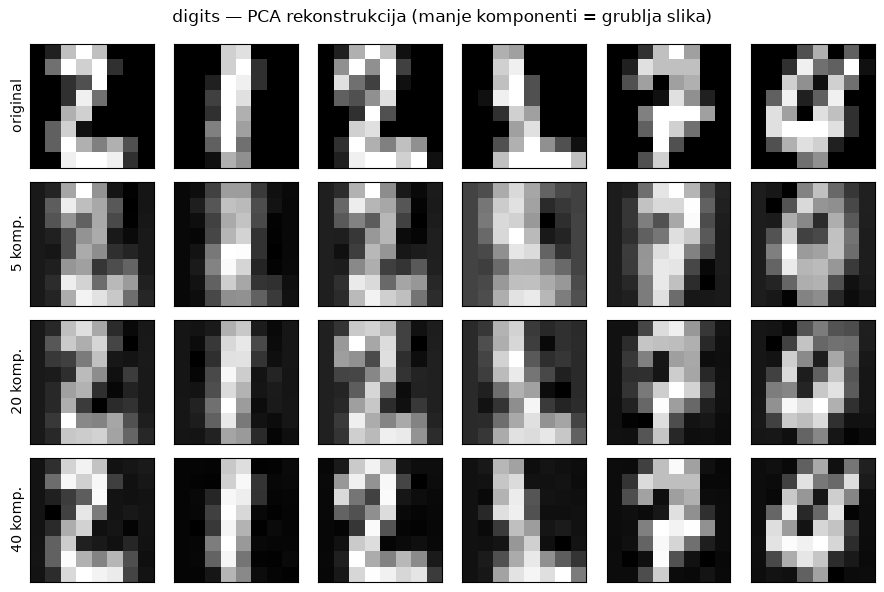

In [49]:
pix = d_dig["Xtr_raw"]
rows = [("original", None), ("5 komp.", 5), ("20 komp.", 20), ("40 komp.", 40)]
fig, axes = plt.subplots(4, 6, figsize=(9, 6))
for r, (lab, ncomp) in enumerate(rows):
    if ncomp is None:
        imgs = pix
    else:
        pr = PCA(n_components=ncomp, random_state=RS).fit(pix)
        imgs = pr.inverse_transform(pr.transform(pix))
    for col in range(6):
        axes[r, col].imshow(imgs[col].reshape(8, 8), cmap="gray")
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
    axes[r, 0].set_ylabel(lab, fontsize=10)
plt.suptitle("digits — PCA rekonstrukcija (manje komponenti = grublja slika)")
plt.tight_layout(); plt.show()

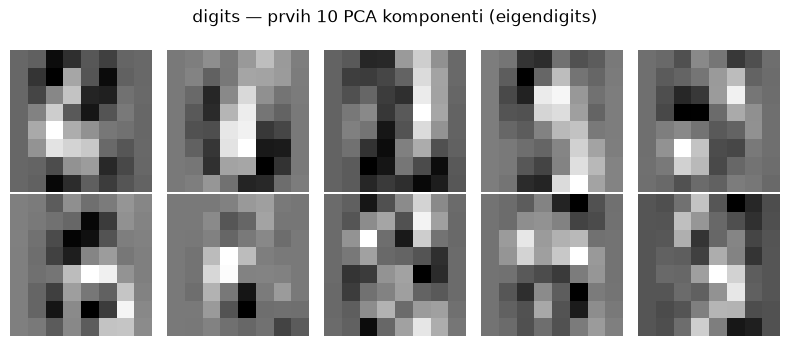

In [50]:
pr = PCA(n_components=10, random_state=RS).fit(d_dig["Xtr_raw"])
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, comp in zip(axes.ravel(), pr.components_):
    ax.imshow(comp.reshape(8, 8), cmap="gray"); ax.axis("off")
plt.suptitle("digits — prvih 10 PCA komponenti (eigendigits)")
plt.tight_layout(); plt.show()

<h3>Rekonstrukcija autoenkoderom</h3><p>Autoencoder rekonstruiše ulaz kroz uski 10D latentni sloj; poređenje originala i rekonstrukcije pokazuje šta je mreža uspela da sažme.</p>

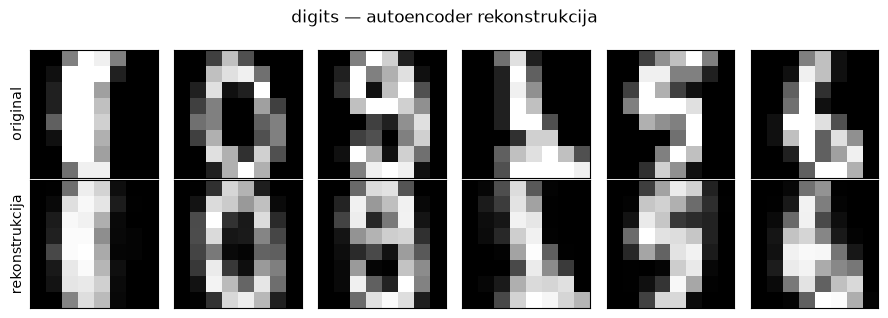

In [51]:
rec_ae = autoencoder.predict(X_ae_te, verbose=0)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for col in range(6):
    axes[0, col].imshow(X_ae_te[col].reshape(8, 8), cmap="gray")
    axes[1, col].imshow(rec_ae[col].reshape(8, 8), cmap="gray")
    for r in range(2):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("rekonstrukcija")
plt.suptitle("digits — autoencoder rekonstrukcija"); plt.tight_layout(); plt.show()

<h3>Confusion matrica</h3><p>Gde model najviše greši? Confusion matrica za k-NN na LDA reprezentaciji.</p>

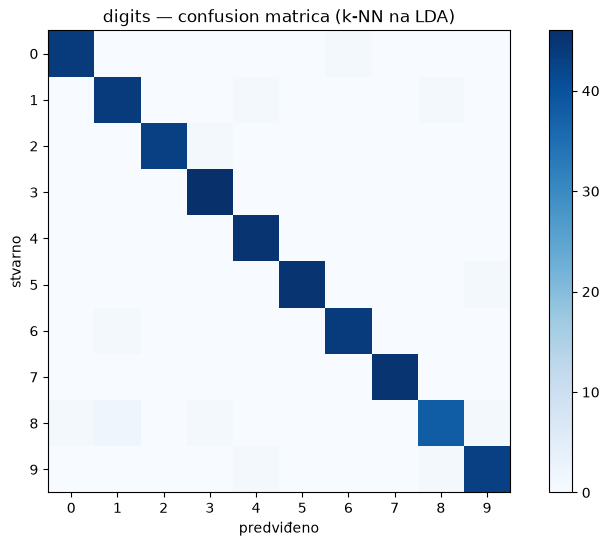

In [52]:
from sklearn.metrics import confusion_matrix
knn = KNeighborsClassifier(n_neighbors=5).fit(Xtr_l, d_dig["ytr"])
cm = confusion_matrix(d_dig["yte"], knn.predict(Xte_l))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xlabel("predviđeno"); plt.ylabel("stvarno")
plt.xticks(range(10)); plt.yticks(range(10))
plt.title("digits — confusion matrica (k-NN na LDA)"); plt.show()

<h1>8 Cross-validation</h1>

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def cv_report(name, pipe, X, y):
    s = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    print(f"{name:36s} {s.mean():.3f} ± {s.std():.3f}")

In [54]:
cv_report("synthetic baseline (k-NN, 500D)",
          Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier())]), X_syn, y_syn)
cv_report("synthetic RF-select (k-NN, 20D)",
          Pipeline([("sc", StandardScaler()),
                    ("sel", SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=RS),
                                            threshold=-np.inf, max_features=20)),
                    ("clf", KNeighborsClassifier())]), X_syn, y_syn)

synthetic baseline (k-NN, 500D)      0.699 ± 0.026
synthetic RF-select (k-NN, 20D)      0.913 ± 0.018


In [55]:
cv_report("digits baseline (k-NN, 64D)",
          Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier())]), X_dig, y_dig)
cv_report("digits LDA (k-NN, 9D)",
          Pipeline([("sc", StandardScaler()),
                    ("lda", LinearDiscriminantAnalysis()),
                    ("clf", KNeighborsClassifier())]), X_dig, y_dig)

digits baseline (k-NN, 64D)          0.944 ± 0.013
digits LDA (k-NN, 9D)                0.933 ± 0.022


In [56]:
cv_report("breast_cancer baseline (LogReg, 30D)",
          Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]), X_bc, y_bc)
cv_report("breast_cancer L1 (LogReg, ~7D)",
          Pipeline([("sc", StandardScaler()),
                    ("sel", SelectFromModel(LogisticRegression(l1_ratio=1, solver="liblinear",
                                                               C=0.1, max_iter=5000, random_state=RS))),
                    ("clf", LogisticRegression(max_iter=5000))]), X_bc, y_bc)

breast_cancer baseline (LogReg, 30D) 0.981 ± 0.007
breast_cancer L1 (LogReg, ~7D)       0.967 ± 0.007


<h1>9 Zakljucak</h1>

In [57]:
pd.DataFrame(results)

,dataset,technique,model,n_dims,accuracy,macro_f1,fit_s,predict_s
0,synthetic,baseline,k-NN,500,0.7140,0.7121,0.0018,1.6803
1,synthetic,baseline,LogReg,500,0.7400,0.7400,0.0137,0.0005
2,breast_cancer,baseline,k-NN,30,0.9790,0.9772,0.0005,0.0023
3,breast_cancer,baseline,LogReg,30,0.9860,0.9850,0.0034,0.0001
4,digits,baseline,k-NN,64,0.9644,0.9642,0.0004,0.0022
5,digits,baseline,LogReg,64,0.9778,0.9776,0.0116,0.0002
6,synthetic,mutual info (k=20),k-NN,20,0.8400,0.8399,0.0003,0.0026
7,synthetic,mutual info (k=20),LogReg,20,0.7900,0.7899,0.0064,0.0002
8,synthetic,RFE (20),k-NN,20,0.9060,0.9060,0.0003,0.0033
9,synthetic,RFE (20),LogReg,20,0.8080,0.8080,0.0045,0.0001
